In [1]:
import json
from collections import Counter
from matplotlib import pyplot as plt

In [2]:
with open('1-raw/pakmcqs_general_knowledge.json', 'r') as f:
    pak_mcqs = json.load(f)

In [3]:
len(pak_mcqs)

459

In [4]:
pak_mcqs[0]

{'domain': 'Urdu General Knowledge',
 'question': 'اردو کس زبان کا لفظ ؟',
 'options': {'A': 'ترکی',
  'B': 'عربی',
  'C': 'فارسی',
  'D': 'ان میں سے کوئی نہیں'},
 'correct_option': 'ترکی',
 'correct_index': 0,
 'page': 1,
 'source_url': 'https://pakmcqs.com/urdu-general-knowledge/sdfasdf1',
 'submitted_by': None,
 'level': ''}

In [5]:
# unique subdomains in native_mcqs
subdomains = set(mcq['domain'] for mcq in pak_mcqs)
subdomains

{'Urdu General Knowledge'}

In [6]:
subdomain_mapping = {
    "Urdu General Knowledge": "general knowledge",
}

mapped_subdomains = [subdomain_mapping.get(subdomain, subdomain) for subdomain in subdomains]
mapped_subdomain_counts = Counter(mapped_subdomains)

# update the std_subdomain key in native_data with mapped subdomain
for mcq in pak_mcqs:
    original_subdomain = mcq['domain']
    mapped_subdomain = subdomain_mapping.get(original_subdomain, original_subdomain)
    mcq['subdomain'] = mapped_subdomain

In [7]:
# unique subdomains in native_mcqs
subdomains = set(mcq['subdomain'] for mcq in pak_mcqs)
subdomains

{'general knowledge'}

In [8]:
# add source key with the values as mcqtimes
for item in pak_mcqs:
    item['source'] = 'pakmcqs'
    item.pop("page")
    item.pop("submitted_by")

In [9]:
pak_mcqs[0]

{'domain': 'Urdu General Knowledge',
 'question': 'اردو کس زبان کا لفظ ؟',
 'options': {'A': 'ترکی',
  'B': 'عربی',
  'C': 'فارسی',
  'D': 'ان میں سے کوئی نہیں'},
 'correct_option': 'ترکی',
 'correct_index': 0,
 'source_url': 'https://pakmcqs.com/urdu-general-knowledge/sdfasdf1',
 'level': '',
 'subdomain': 'general knowledge',
 'source': 'pakmcqs'}

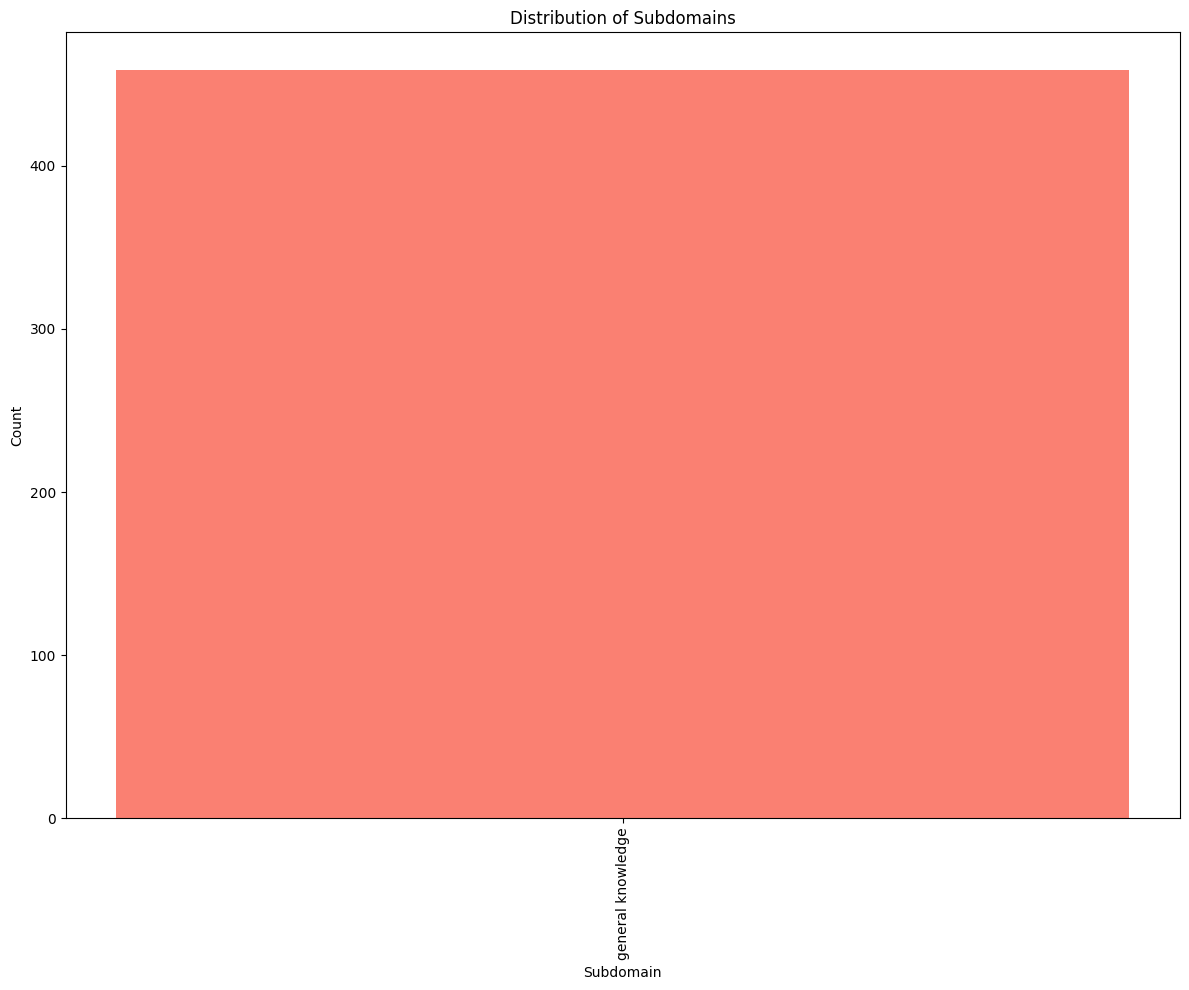

In [10]:
subdomains = [item['subdomain'] for item in pak_mcqs]
subdomain_counts = Counter(subdomains)

# rotate x-axis labels for better readability to 90 degrees
plt.figure(figsize=(12, 10))
plt.bar(subdomain_counts.keys(), subdomain_counts.values(), color='salmon')
plt.title('Distribution of Subdomains')
plt.xlabel('Subdomain')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [11]:
with open('2-processed/pakmcqs.json', 'w', encoding='utf-8') as f:
    json.dump(pak_mcqs, f, ensure_ascii=False, indent=4)